In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [54]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data"
column_names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class'
]
df = pd.read_csv(url, names=column_names)
print(df)

        fLength    fWidth   fSize   fConc  fConc1     fAsym   fM3Long  \
0       28.7967   16.0021  2.6449  0.3918  0.1982   27.7004   22.0110   
1       31.6036   11.7235  2.5185  0.5303  0.3773   26.2722   23.8238   
2      162.0520  136.0310  4.0612  0.0374  0.0187  116.7410  -64.8580   
3       23.8172    9.5728  2.3385  0.6147  0.3922   27.2107   -6.4633   
4       75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277   28.5525   
...         ...       ...     ...     ...     ...       ...       ...   
19015   21.3846   10.9170  2.6161  0.5857  0.3934   15.2618   11.5245   
19016   28.9452    6.7020  2.2672  0.5351  0.2784   37.0816   13.1853   
19017   75.4455   47.5305  3.4483  0.1417  0.0549   -9.3561   41.0562   
19018  120.5135   76.9018  3.9939  0.0944  0.0683    5.8043  -93.5224   
19019  187.1814   53.0014  3.2093  0.2876  0.1539 -167.3125 -168.4558   

       fM3Trans   fAlpha     fDist class  
0       -8.2027  40.0920   81.8828     g  
1       -9.9574   6.3609  205.2610   

In [55]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (19020, 11)


In [56]:
duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Dropped {duplicates} duplicates successfully.")

Dropped 115 duplicates successfully.


In [57]:
df['class'] = df['class'].map({'g': 1, 'h': 0})

In [58]:
numerical_features = column_names[:-1]
df_clean = df.copy()
for col in numerical_features:
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

In [61]:
X = df_clean.drop(columns=['class'])
y = df_clean['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()

scaler.fit(X_train[numerical_features])

X_train_scaled_numerical = scaler.transform(X_train[numerical_features])
X_test_scaled_numerical = scaler.transform(X_test[numerical_features])

X_train_scaled = pd.DataFrame(X_train_scaled_numerical, columns=numerical_features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_numerical, columns=numerical_features, index=X_test.index)



Confusion Matrix:
[[ 396  444]
 [ 164 1989]]


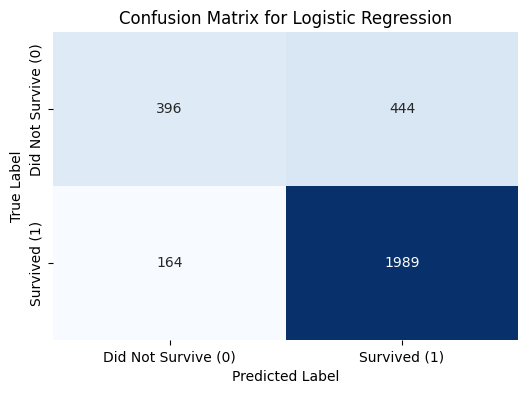


Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.47      0.57       840
           1       0.82      0.92      0.87      2153

    accuracy                           0.80      2993
   macro avg       0.76      0.70      0.72      2993
weighted avg       0.79      0.80      0.78      2993



In [64]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Did Not Survive (0)', 'Survived (1)'],
            yticklabels=['Did Not Survive (0)', 'Survived (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

clf_report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", clf_report)